In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('Visadataset.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [14]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [16]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
categorical_features = df.select_dtypes(include=['str']).columns.to_list()

In [17]:
for cat in categorical_features:
    print(df[cat].value_counts())
    print('---------------------------')

case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
---------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
---------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
---------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
---------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
---------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
---------------------------
unit_of_wage
Year     22962
Hour      

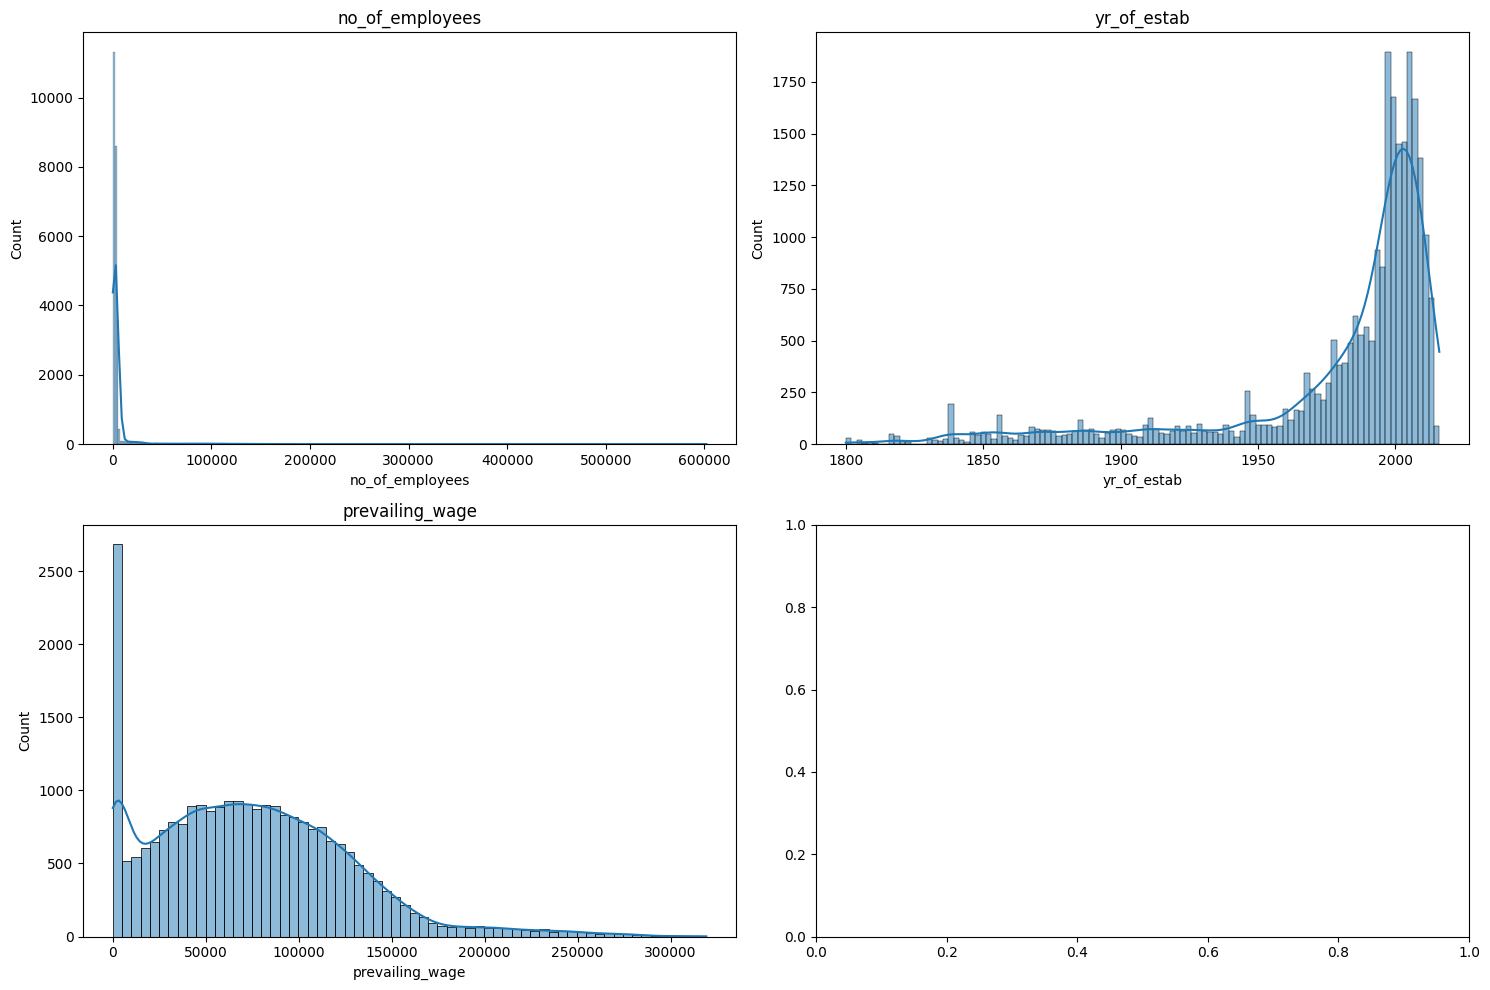

In [18]:
#univairet analysis for numerical analysis
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout() #This prevents plots from overlapping and adjusts spacing automatically.
plt.show()

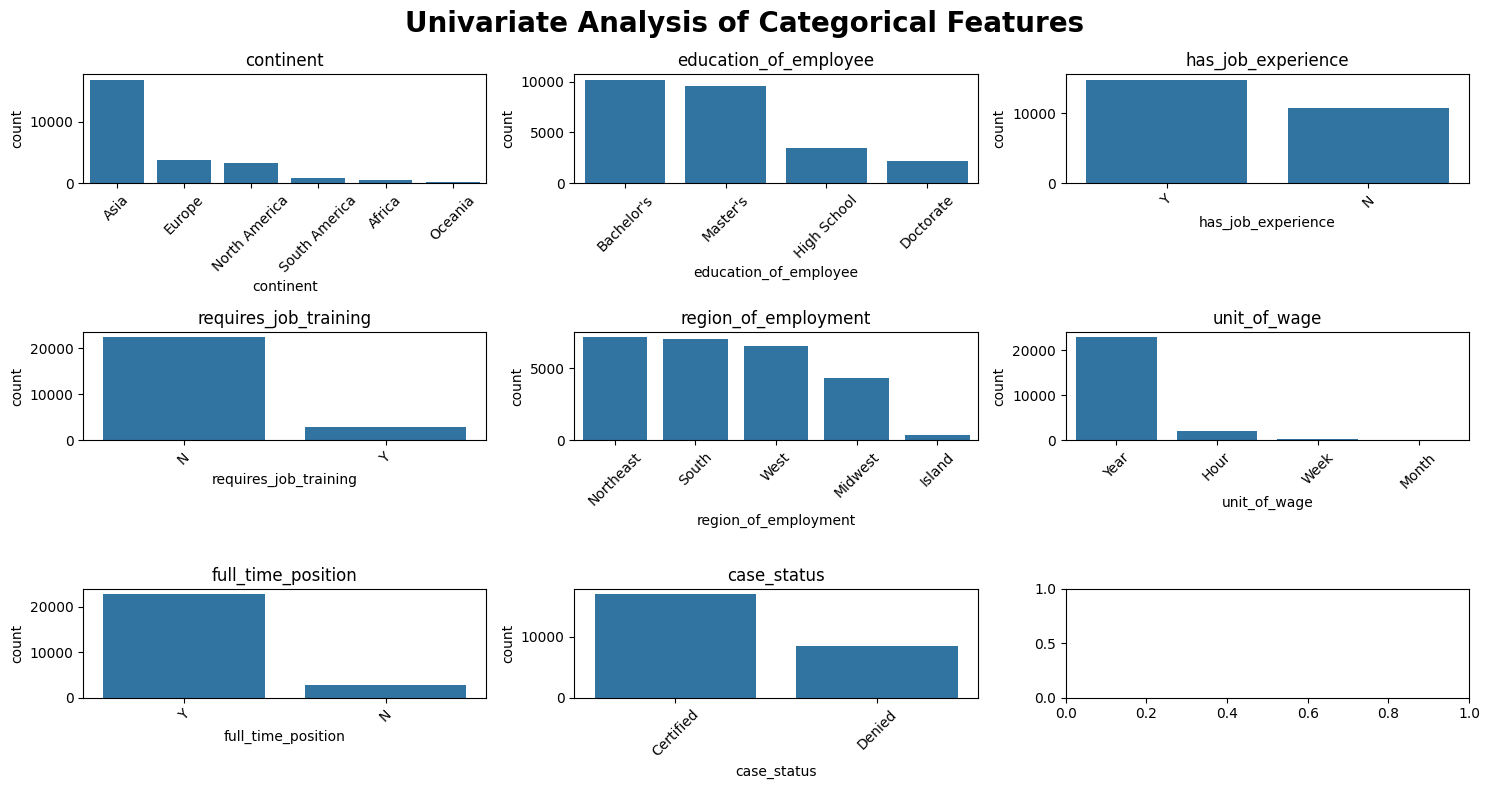

In [19]:
categorical_features.remove('case_id')

n = len(categorical_features)

fig, axes = plt.subplots(3, 3, figsize=(15,8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=df, x=feature, ax=axes[i], order=df[feature].value_counts().index)
    
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle(
    'Univariate Analysis of Categorical Features',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import chi2_contingency
import pandas as pd

results = []

for col in categorical_features:
    
    contingency_table = pd.crosstab(df[col], df['case_status'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        "Feature": col,
        "Chi2 Statistic": chi2,
        "P-value": p_value,
        "Result": "Reject H0 (Dependent)" if p_value < 0.05 else "Fail to Reject H0 (Independent)"
    })

chi2_df = pd.DataFrame(results)

chi2_df.sort_values("P-value")

,Feature,Chi2 Statistic,P-value,Result
1,education_of_employee,2772.207275,0.000000e+00,Reject H0 (Dependent)
7,case_status,25475.491853,0.000000e+00,Reject H0 (Dependent)
5,unit_of_wage,1108.507062,5.193385e-240,Reject H0 (Dependent)
2,has_job_experience,940.058096,1.922560e-206,Reject H0 (Dependent)
0,continent,351.380408,8.828798e-74,Reject H0 (Dependent)
4,region_of_employment,298.450836,2.338664e-63,Reject H0 (Dependent)
6,full_time_position,4.029932,4.469975e-02,Reject H0 (Dependent)
3,requires_job_training,1.752484,1.855647e-01,Fail to Reject H0 (Independent)


In [25]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [29]:
discrete_features = [col for col in numeric_features if df[col].nunique() <=10]
continues_features = [col for col in numeric_features if col not in discrete_features]
continues_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

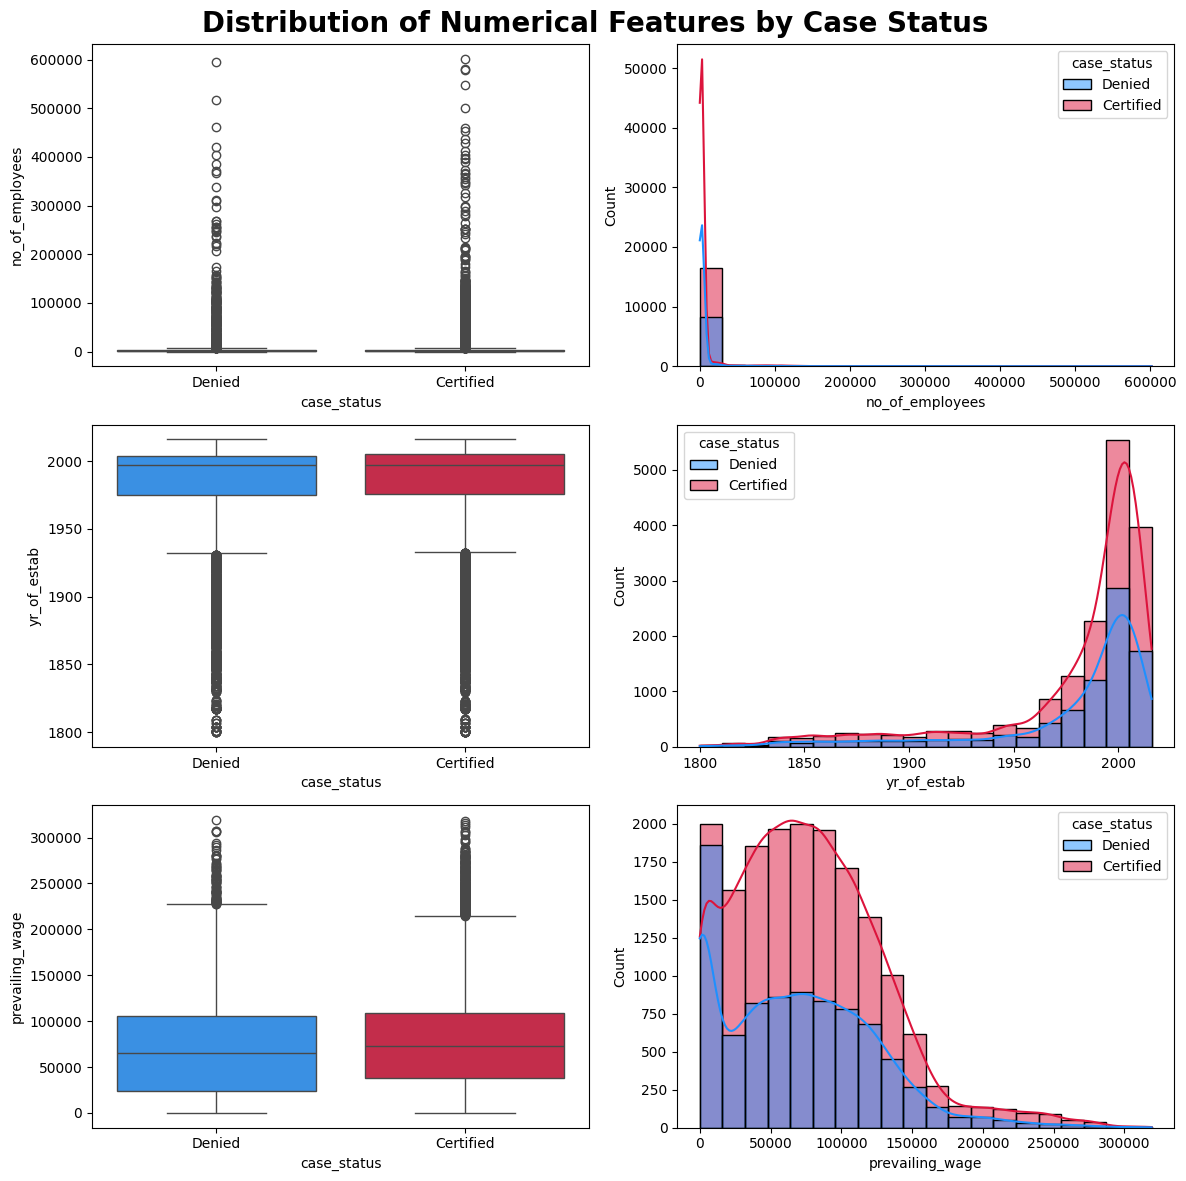

In [31]:

clr = ['#1E90FF', '#DC143C']

fig, axes = plt.subplots(len(continues_features), 2, figsize=(12, 4*len(continues_features)))

fig.suptitle(
    'Distribution of Numerical Features by Case Status',
    fontsize=20,
    fontweight='bold'
)

for i, col in enumerate(continues_features):

    sns.boxplot(
        data=df,
        x='case_status',
        y=col,
        hue='case_status',
        palette=clr,
        legend=False,
        ax=axes[i,0]
    )

    sns.histplot(
        data=df,
        x=col,
        hue='case_status',
        bins=20,
        kde=True,
        palette=clr,
        ax=axes[i,1]
    )

plt.tight_layout()
plt.show()